In [1]:
"""
日内交易研究 - VWAP时段选择预测
================================
研究目标: 预测 vwap_am vs vwap_pm 的相对价值，决定最优交易时段
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 数据路径配置
CACHE_DIR = "/nfs/ofs-prediction/peterzhenglinpeng/backtest_engine/cache_dir"
VWAP_POST_FILE = f"{CACHE_DIR}/vwap_post.csv"
VWAP_UNADJUSTED_FILE = f"{CACHE_DIR}/vwap_unadjusted.csv"
OHLC_FILE = f"{CACHE_DIR}/ohlc_prices.csv"

print("数据路径配置完成")

数据路径配置完成


In [2]:
# 加载后复权VWAP数据 (用于分析日内波动)
print("加载 vwap_post.csv ...")
vwap_df = pd.read_csv(VWAP_POST_FILE)
vwap_df["datetime"] = pd.to_datetime(vwap_df["datetime"])

# 重命名列以简化后续代码 (post_vwap_am -> vwap_am)
vwap_df = vwap_df.rename(
    columns={"post_vwap_am": "vwap_am", "post_vwap_pm": "vwap_pm", "post_vwap": "vwap"}
)

print(f"数据形状: {vwap_df.shape}")
print(f"日期范围: {vwap_df['datetime'].min()} ~ {vwap_df['datetime'].max()}")
print(f"股票数量: {vwap_df['order_book_id'].nunique()}")
print(f"列名: {list(vwap_df.columns)}")
vwap_df.head()

加载 vwap_post.csv ...
数据形状: (13654837, 5)
日期范围: 2010-01-04 00:00:00 ~ 2026-01-26 00:00:00
股票数量: 5438
列名: ['order_book_id', 'datetime', 'vwap_am', 'vwap_pm', 'vwap']


,order_book_id,datetime,vwap_am,vwap_pm,vwap
0,000001.XSHE,2010-01-04,1150.067610,1132.728160,1139.954623
1,000001.XSHE,2010-01-05,1100.330981,1109.961335,1104.697068
2,000001.XSHE,2010-01-06,1089.672967,1088.432100,1089.136080
3,000001.XSHE,2010-01-07,1077.880312,1072.834545,1075.610836
4,000001.XSHE,2010-01-08,1072.909667,1070.785830,1071.761018


In [3]:
# 选取典型股票进行分析
# 大盘股: 平安银行 000001.XSHE, 招商银行 600036.XSHG, 贵州茅台 600519.XSHG
# 中盘股: 宁德时代 300750.XSHE, 比亚迪 002594.XSHE
# 小盘股: 随机选几只市值较小的股票

SAMPLE_STOCKS = {
    "大盘股": [
        "000001.XSHE",
        "600036.XSHG",
        "600519.XSHG",
    ],  # 平安银行、招商银行、贵州茅台
    "中盘股": ["300750.XSHE", "002594.XSHE"],  # 宁德时代、比亚迪
    "小盘股": [
        "300059.XSHE",
        "002475.XSHE",
        "300033.XSHE",
    ],  # 东方财富、立讯精密、同花顺
}

STOCK_NAMES = {
    "000001.XSHE": "平安银行",
    "600036.XSHG": "招商银行",
    "600519.XSHG": "贵州茅台",
    "300750.XSHE": "宁德时代",
    "002594.XSHE": "比亚迪",
    "300059.XSHE": "东方财富",
    "002475.XSHE": "立讯精密",
    "300033.XSHE": "同花顺",
}

# 检查这些股票是否在数据中
available_stocks = set(vwap_df["order_book_id"].unique())
for category, stocks in SAMPLE_STOCKS.items():
    for stock in stocks:
        status = "✅" if stock in available_stocks else "❌"
        print(f"{status} {category}: {stock} ({STOCK_NAMES.get(stock, 'Unknown')})")

✅ 大盘股: 000001.XSHE (平安银行)
✅ 大盘股: 600036.XSHG (招商银行)
✅ 大盘股: 600519.XSHG (贵州茅台)
✅ 中盘股: 300750.XSHE (宁德时代)
✅ 中盘股: 002594.XSHE (比亚迪)
✅ 小盘股: 300059.XSHE (东方财富)
✅ 小盘股: 002475.XSHE (立讯精密)
✅ 小盘股: 300033.XSHE (同花顺)


In [4]:
# 计算日内价格偏离指标: spread = (vwap_am - vwap_pm) / vwap
# spread > 0: 上午贵、下午便宜
# spread < 0: 上午便宜、下午贵


def calculate_spread(df):
    """计算日内价格偏离"""
    df = df.copy()
    df["spread"] = (df["vwap_am"] - df["vwap_pm"]) / df["vwap"]
    df["spread_bps"] = df["spread"] * 10000  # 转换为基点 (bps)
    return df


vwap_df = calculate_spread(vwap_df)

# 查看spread的分布
print("=" * 60)
print("日内价格偏离 (spread) 统计")
print("=" * 60)
print(f"均值: {vwap_df['spread_bps'].mean():.2f} bps")
print(f"中位数: {vwap_df['spread_bps'].median():.2f} bps")
print(f"标准差: {vwap_df['spread_bps'].std():.2f} bps")
print(f"最小值: {vwap_df['spread_bps'].min():.2f} bps")
print(f"最大值: {vwap_df['spread_bps'].max():.2f} bps")
print(f"5%分位: {vwap_df['spread_bps'].quantile(0.05):.2f} bps")
print(f"95%分位: {vwap_df['spread_bps'].quantile(0.95):.2f} bps")

日内价格偏离 (spread) 统计
均值: -0.53 bps
中位数: 5.79 bps
标准差: 151.05 bps
最小值: -11310.76 bps
最大值: 3498.80 bps
5%分位: -244.17 bps
95%分位: 218.34 bps


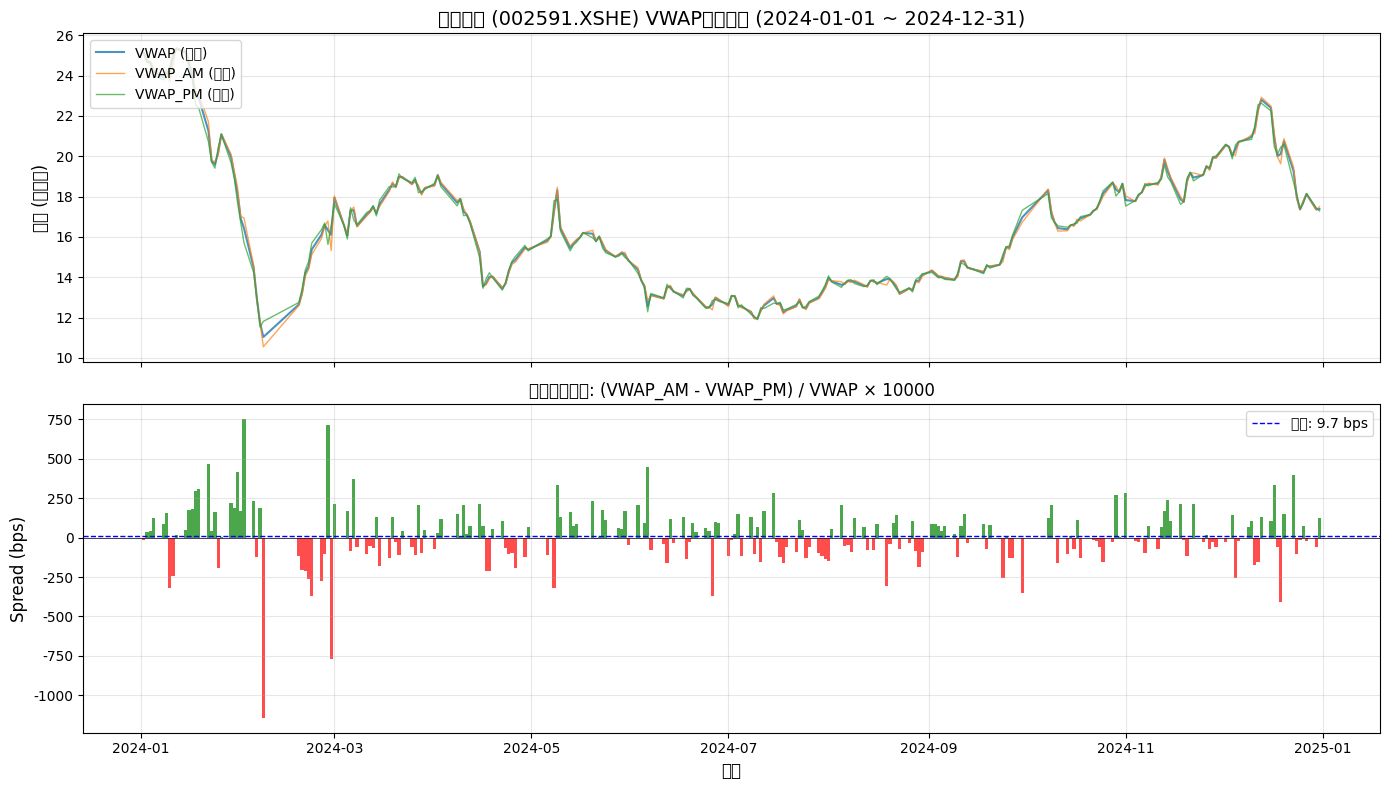


恒大高新 (002591.XSHE) 日内偏离统计:
  均值: 9.70 bps
  标准差: 185.89 bps
  >0 (上午贵) 占比: 48.8%
  <0 (下午贵) 占比: 51.2%


In [8]:
# 画图1: 单只股票的 vwap, vwap_am, vwap_pm 时序对比
def plot_vwap_comparison(
    stock_code, stock_name, start_date="2024-01-01", end_date="2024-12-31"
):
    """画单只股票的VWAP时序对比图"""
    stock_df = (
        vwap_df[
            (vwap_df["order_book_id"] == stock_code)
            & (vwap_df["datetime"] >= start_date)
            & (vwap_df["datetime"] <= end_date)
        ]
        .copy()
        .sort_values("datetime")
    )

    if stock_df.empty:
        print(f"没有找到 {stock_code} 的数据")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # 上图: VWAP价格走势
    ax1 = axes[0]
    ax1.plot(
        stock_df["datetime"],
        stock_df["vwap"],
        label="VWAP (全天)",
        linewidth=1.5,
        alpha=0.8,
    )
    ax1.plot(
        stock_df["datetime"],
        stock_df["vwap_am"],
        label="VWAP_AM (上午)",
        linewidth=1,
        alpha=0.7,
    )
    ax1.plot(
        stock_df["datetime"],
        stock_df["vwap_pm"],
        label="VWAP_PM (下午)",
        linewidth=1,
        alpha=0.7,
    )
    ax1.set_ylabel("价格 (后复权)", fontsize=12)
    ax1.set_title(
        f"{stock_name} ({stock_code}) VWAP日内对比 ({start_date} ~ {end_date})",
        fontsize=14,
    )
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # 下图: spread (上午-下午) 基点
    ax2 = axes[1]
    colors = ["green" if x > 0 else "red" for x in stock_df["spread_bps"]]
    ax2.bar(
        stock_df["datetime"], stock_df["spread_bps"], color=colors, alpha=0.7, width=1
    )
    ax2.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax2.axhline(
        y=stock_df["spread_bps"].mean(),
        color="blue",
        linestyle="--",
        linewidth=1,
        label=f'均值: {stock_df["spread_bps"].mean():.1f} bps',
    )
    ax2.set_ylabel("Spread (bps)", fontsize=12)
    ax2.set_xlabel("日期", fontsize=12)
    ax2.set_title("日内价格偏离: (VWAP_AM - VWAP_PM) / VWAP × 10000", fontsize=12)
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 打印统计
    print(f"\n{stock_name} ({stock_code}) 日内偏离统计:")
    print(f"  均值: {stock_df['spread_bps'].mean():.2f} bps")
    print(f"  标准差: {stock_df['spread_bps'].std():.2f} bps")
    print(f"  >0 (上午贵) 占比: {(stock_df['spread_bps'] > 0).mean()*100:.1f}%")
    print(f"  <0 (下午贵) 占比: {(stock_df['spread_bps'] < 0).mean()*100:.1f}%")


# 测试: 平安银行
plot_vwap_comparison("002591.XSHE", "恒大高新", "2024-01-01", "2024-12-31")

各股票日内偏离统计 (2024年)
order_book_id stock_name category      mean        std    median  positive_ratio
  000001.XSHE       平安银行      大盘股 -0.422963  62.344443  3.409740        0.534930
  002475.XSHE       立讯精密      小盘股 -0.057664 124.575552 10.785635        0.542914
  002594.XSHE        比亚迪      中盘股  0.217043  91.437033  7.272680        0.548902
  300033.XSHE        同花顺      小盘股 -6.842421 196.299003 16.437609        0.554890
  300059.XSHE       东方财富      小盘股 -1.790452 151.579427 14.522799        0.574850
  300750.XSHE       宁德时代      中盘股 -0.349129 108.354801  3.617294        0.520958
  600036.XSHG       招商银行      大盘股 -3.684964  62.826423 -1.574420        0.479042
  600519.XSHG       贵州茅台      大盘股  2.793779  71.192217  6.447035        0.564870


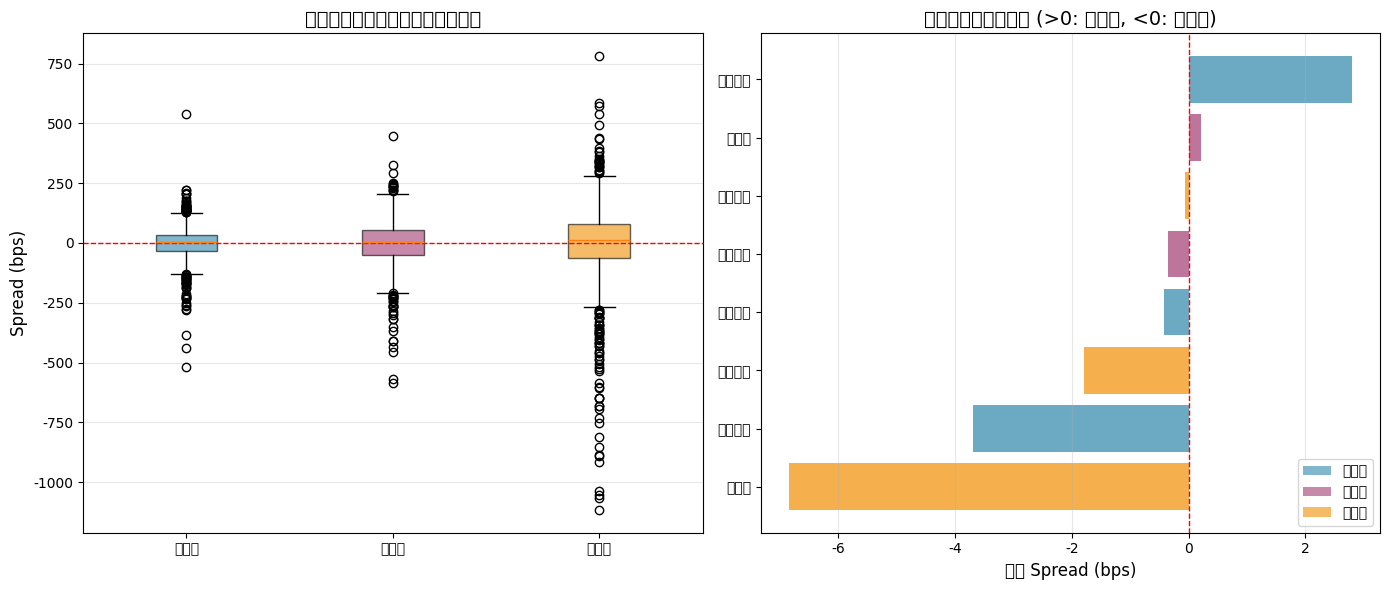

In [9]:
# 画图2: 不同市值股票的日内偏离对比 (箱线图)
def plot_spread_by_market_cap():
    """按市值分组画日内偏离箱线图"""

    # 筛选样本股票，取2024年数据
    all_stocks = [s for stocks in SAMPLE_STOCKS.values() for s in stocks]
    sample_df = vwap_df[
        (vwap_df["order_book_id"].isin(all_stocks))
        & (vwap_df["datetime"] >= "2024-01-01")
    ].copy()

    # 添加市值分类
    def get_category(stock):
        for cat, stocks in SAMPLE_STOCKS.items():
            if stock in stocks:
                return cat
        return "其他"

    sample_df["category"] = sample_df["order_book_id"].map(get_category)
    sample_df["stock_name"] = sample_df["order_book_id"].map(STOCK_NAMES)

    # 按股票聚合统计
    stock_stats = (
        sample_df.groupby(["order_book_id", "stock_name", "category"])["spread_bps"]
        .agg(["mean", "std", "median", ("positive_ratio", lambda x: (x > 0).mean())])
        .reset_index()
    )

    print("=" * 80)
    print("各股票日内偏离统计 (2024年)")
    print("=" * 80)
    print(stock_stats.to_string(index=False))

    # 箱线图
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 左图: 按市值分类的箱线图
    categories = ["大盘股", "中盘股", "小盘股"]
    data_by_cat = [
        sample_df[sample_df["category"] == cat]["spread_bps"].dropna()
        for cat in categories
    ]

    bp = axes[0].boxplot(data_by_cat, labels=categories, patch_artist=True)
    colors = ["#2E86AB", "#A23B72", "#F18F01"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
    axes[0].set_ylabel("Spread (bps)", fontsize=12)
    axes[0].set_title("不同市值股票的日内价格偏离分布", fontsize=14)
    axes[0].grid(True, alpha=0.3, axis="y")

    # 右图: 各股票的均值对比
    stock_stats_sorted = stock_stats.sort_values("mean")
    colors = stock_stats_sorted["category"].map(
        {"大盘股": "#2E86AB", "中盘股": "#A23B72", "小盘股": "#F18F01"}
    )

    axes[1].barh(
        stock_stats_sorted["stock_name"],
        stock_stats_sorted["mean"],
        color=colors,
        alpha=0.7,
    )
    axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
    axes[1].set_xlabel("平均 Spread (bps)", fontsize=12)
    axes[1].set_title("各股票日内偏离均值 (>0: 上午贵, <0: 下午贵)", fontsize=14)
    axes[1].grid(True, alpha=0.3, axis="x")

    # 添加图例
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor="#2E86AB", alpha=0.6, label="大盘股"),
        Patch(facecolor="#A23B72", alpha=0.6, label="中盘股"),
        Patch(facecolor="#F18F01", alpha=0.6, label="小盘股"),
    ]
    axes[1].legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()
    plt.show()


plot_spread_by_market_cap()

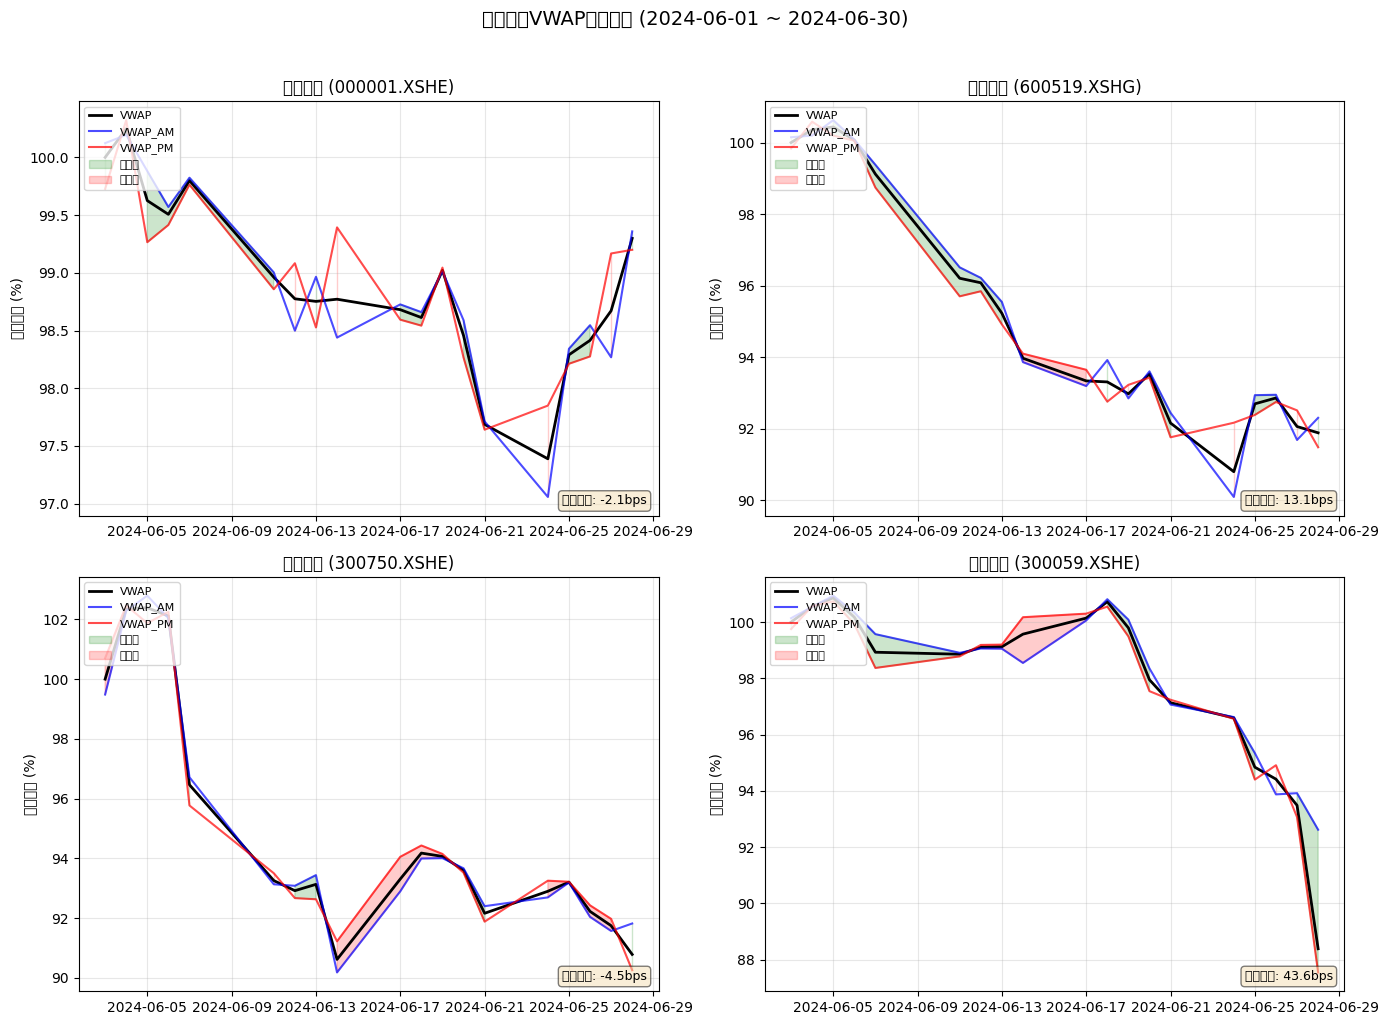

In [10]:
# 画图3: 不同股票的VWAP日内走势对比 (选取几天)
def plot_multi_stock_vwap(date_range=("2024-06-01", "2024-06-30")):
    """多只股票的VWAP对比"""

    # 选取代表性股票
    stocks_to_plot = ["000001.XSHE", "600519.XSHG", "300750.XSHE", "300059.XSHE"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, stock_code in enumerate(stocks_to_plot):
        stock_name = STOCK_NAMES.get(stock_code, stock_code)
        stock_df = (
            vwap_df[
                (vwap_df["order_book_id"] == stock_code)
                & (vwap_df["datetime"] >= date_range[0])
                & (vwap_df["datetime"] <= date_range[1])
            ]
            .copy()
            .sort_values("datetime")
        )

        if stock_df.empty:
            axes[idx].set_title(f"{stock_name}: 无数据")
            continue

        # 归一化到第一天
        base_price = stock_df["vwap"].iloc[0]

        ax = axes[idx]
        ax.plot(
            stock_df["datetime"],
            stock_df["vwap"] / base_price * 100,
            label="VWAP",
            linewidth=2,
            color="black",
        )
        ax.plot(
            stock_df["datetime"],
            stock_df["vwap_am"] / base_price * 100,
            label="VWAP_AM",
            linewidth=1.5,
            color="blue",
            alpha=0.7,
        )
        ax.plot(
            stock_df["datetime"],
            stock_df["vwap_pm"] / base_price * 100,
            label="VWAP_PM",
            linewidth=1.5,
            color="red",
            alpha=0.7,
        )

        # 填充上午贵/下午贵的区域
        ax.fill_between(
            stock_df["datetime"],
            stock_df["vwap_am"] / base_price * 100,
            stock_df["vwap_pm"] / base_price * 100,
            where=(stock_df["vwap_am"] > stock_df["vwap_pm"]),
            color="green",
            alpha=0.2,
            label="上午贵",
        )
        ax.fill_between(
            stock_df["datetime"],
            stock_df["vwap_am"] / base_price * 100,
            stock_df["vwap_pm"] / base_price * 100,
            where=(stock_df["vwap_am"] < stock_df["vwap_pm"]),
            color="red",
            alpha=0.2,
            label="下午贵",
        )

        ax.set_title(f"{stock_name} ({stock_code})", fontsize=12)
        ax.set_ylabel("相对价格 (%)", fontsize=10)
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.3)

        # 显示统计
        mean_spread = stock_df["spread_bps"].mean()
        ax.text(
            0.98,
            0.02,
            f"平均偏离: {mean_spread:.1f}bps",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )

    plt.suptitle(
        f"不同股票VWAP日内对比 ({date_range[0]} ~ {date_range[1]})", fontsize=14, y=1.02
    )
    plt.tight_layout()
    plt.show()


plot_multi_stock_vwap(("2024-06-01", "2024-06-30"))

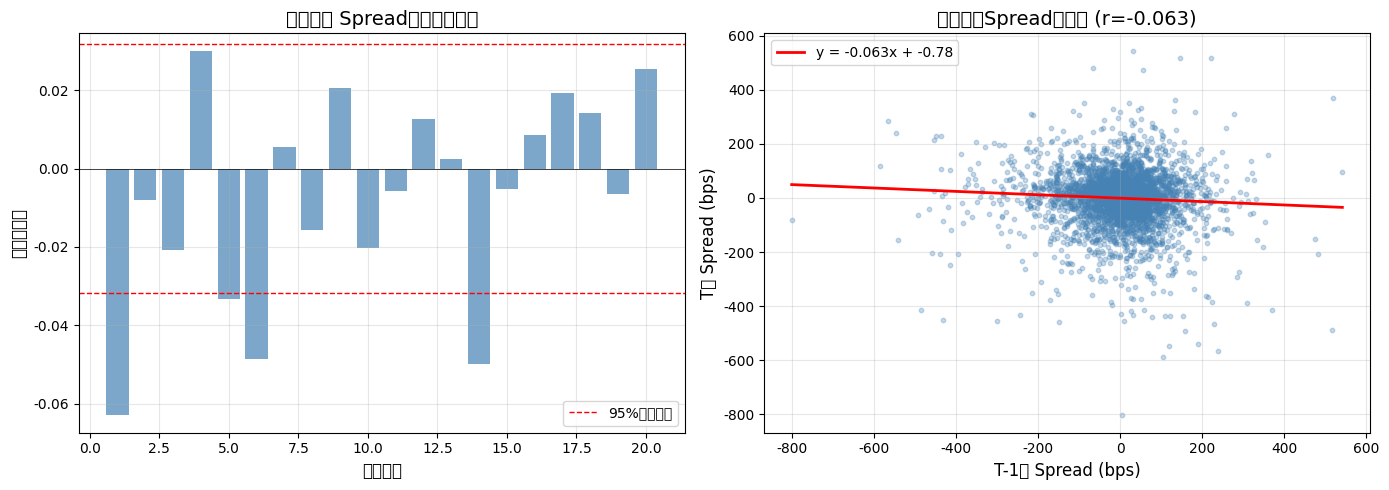


平安银行 Spread自相关分析:
  1日滞后相关: -0.0627
  5日滞后相关: -0.0332
  10日滞后相关: -0.0203
  结论: 无显著延续性


In [ ]:
# 画图4: Spread的自相关性分析 (验证日内模式是否有延续性)
def plot_spread_autocorrelation(stock_code="000001.XSHE"):
    """分析spread的自相关性"""
    stock_df = (
        vwap_df[vwap_df["order_book_id"] == stock_code].copy().sort_values("datetime")
    )
    stock_name = STOCK_NAMES.get(stock_code, stock_code)

    if stock_df.empty:
        print(f"没有找到 {stock_code} 的数据")
        return

    spread = stock_df["spread_bps"].dropna()

    # 计算自相关系数
    lags = range(1, 21)
    autocorrs = [spread.autocorr(lag=lag) for lag in lags]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 左图: 自相关图
    ax1 = axes[0]
    ax1.bar(lags, autocorrs, color="steelblue", alpha=0.7)
    ax1.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    # 95%置信区间
    n = len(spread)
    conf = 1.96 / np.sqrt(n)
    ax1.axhline(y=conf, color="red", linestyle="--", linewidth=1, label="95%置信区间")
    ax1.axhline(y=-conf, color="red", linestyle="--", linewidth=1)
    ax1.set_xlabel("滞后天数", fontsize=12)
    ax1.set_ylabel("自相关系数", fontsize=12)
    ax1.set_title(f"{stock_name} Spread自相关性分析", fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 右图: T日spread vs T-1日spread 散点图
    ax2 = axes[1]
    spread_t = spread.values[1:]
    spread_t1 = spread.values[:-1]
    ax2.scatter(spread_t1, spread_t, alpha=0.3, s=10, c="steelblue")

    # 拟合线
    z = np.polyfit(spread_t1, spread_t, 1)
    p = np.poly1d(z)
    x_line = np.linspace(spread_t1.min(), spread_t1.max(), 100)
    ax2.plot(
        x_line, p(x_line), "r-", linewidth=2, label=f"y = {z[0]:.3f}x + {z[1]:.2f}"
    )

    corr = np.corrcoef(spread_t1, spread_t)[0, 1]
    ax2.set_xlabel("T-1日 Spread (bps)", fontsize=12)
    ax2.set_ylabel("T日 Spread (bps)", fontsize=12)
    ax2.set_title(f"相邻两日Spread相关性 (r={corr:.3f})", fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{stock_name} Spread自相关分析:")
    print(f"  1日滞后相关: {autocorrs[0]:.4f}")
    print(f"  5日滞后相关: {autocorrs[4]:.4f}")
    print(f"  10日滞后相关: {autocorrs[9]:.4f}")
    print(f"  结论: {'有显著延续性' if autocorrs[0] > conf else '无显著延续性'}")


plot_spread_autocorrelation("000001.XSHE")

In [ ]:
"""
===========================================
LightGBM 特征重要性分析示例
===========================================
LightGBM 提供三种特征重要性度量方式:

1. split (分裂次数): 特征被用于分裂的总次数
   - 含义: 特征被模型使用的频率
   - 适用: 了解哪些特征"常用"

2. gain (信息增益): 特征带来的总信息增益
   - 含义: 特征对模型预测能力的贡献度
   - 适用: 了解哪些特征"重要"
   - 推荐: 这是最常用的重要性度量

3. SHAP值 (SHapley Additive exPlanations):
   - 含义: 基于博弈论的特征贡献度，考虑特征交互
   - 优点: 可解释单个样本的预测，正负方向明确
   - 适用: 深入理解模型决策过程
"""

# 演示: 用简单数据训练LightGBM并分析特征重要性
from lightgbm import LGBMRegressor
import shap


# 准备演示数据 (以平安银行为例)
def prepare_demo_features(stock_code="000001.XSHE"):
    """准备演示用的特征数据"""
    stock_df = (
        vwap_df[vwap_df["order_book_id"] == stock_code].copy().sort_values("datetime")
    )

    # 计算特征
    df = stock_df[["datetime", "vwap", "vwap_am", "vwap_pm", "spread_bps"]].copy()

    # 特征1: 前1日spread
    df["spread_lag1"] = df["spread_bps"].shift(1)
    # 特征2: 前5日spread均值
    df["spread_ma5"] = df["spread_bps"].rolling(5).mean().shift(1)
    # 特征3: 前20日spread均值
    df["spread_ma20"] = df["spread_bps"].rolling(20).mean().shift(1)
    # 特征4: 前1日收益率
    df["ret_lag1"] = df["vwap"].pct_change().shift(1) * 100
    # 特征5: 前5日收益率
    df["ret_5d"] = df["vwap"].pct_change(5).shift(1) * 100
    # 特征6: 前5日波动率
    df["volatility_5d"] = df["vwap"].pct_change().rolling(5).std().shift(1) * 100
    # 特征7: 星期几
    df["day_of_week"] = df["datetime"].dt.dayofweek

    # 目标变量: T日的spread
    df["target"] = df["spread_bps"]

    # 去掉NaN
    df = df.dropna()

    return df


demo_df = prepare_demo_features("000001.XSHE")
print(f"样本数量: {len(demo_df)}")
print(
    f"特征列: {['spread_lag1', 'spread_ma5', 'spread_ma20', 'ret_lag1', 'ret_5d', 'volatility_5d', 'day_of_week']}"
)
demo_df.tail()

In [ ]:
# 训练LightGBM模型并分析特征重要性
feature_cols = [
    "spread_lag1",
    "spread_ma5",
    "spread_ma20",
    "ret_lag1",
    "ret_5d",
    "volatility_5d",
    "day_of_week",
]

# 时序切分: 前80%训练，后20%测试
split_idx = int(len(demo_df) * 0.8)
train_df = demo_df.iloc[:split_idx]
test_df = demo_df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df["target"]
X_test, y_test = test_df[feature_cols], test_df["target"]

# 训练模型
model = LGBMRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=16,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
)
model.fit(X_train, y_train)

# 预测并评估
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
ic = np.corrcoef(y_test, y_pred)[0, 1]

print("=" * 60)
print("模型评估结果")
print("=" * 60)
print(f"测试集样本数: {len(y_test)}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")
print(f"IC (相关系数): {ic:.4f}")

In [ ]:
# LightGBM 特征重要性分析 (三种方式)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 方式1: Split (分裂次数)
importance_split = model.feature_importances_  # 默认是split
sorted_idx = np.argsort(importance_split)
axes[0].barh(
    np.array(feature_cols)[sorted_idx], importance_split[sorted_idx], color="steelblue"
)
axes[0].set_xlabel("分裂次数")
axes[0].set_title("特征重要性 - Split (分裂次数)", fontsize=12)
axes[0].grid(True, alpha=0.3, axis="x")

# 方式2: Gain (信息增益)
importance_gain = model.booster_.feature_importance(importance_type="gain")
sorted_idx = np.argsort(importance_gain)
axes[1].barh(
    np.array(feature_cols)[sorted_idx], importance_gain[sorted_idx], color="coral"
)
axes[1].set_xlabel("累计信息增益")
axes[1].set_title("特征重要性 - Gain (信息增益) ★推荐", fontsize=12)
axes[1].grid(True, alpha=0.3, axis="x")

# 方式3: 排列重要性 (Permutation Importance)
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)
sorted_idx = np.argsort(perm_importance.importances_mean)
axes[2].barh(
    np.array(feature_cols)[sorted_idx],
    perm_importance.importances_mean[sorted_idx],
    xerr=perm_importance.importances_std[sorted_idx],
    color="seagreen",
)
axes[2].set_xlabel("排列重要性 (R² 下降)")
axes[2].set_title("特征重要性 - Permutation", fontsize=12)
axes[2].grid(True, alpha=0.3, axis="x")

plt.suptitle("LightGBM 三种特征重要性度量对比", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 打印特征重要性排名
print("\n" + "=" * 60)
print("特征重要性排名 (按Gain排序)")
print("=" * 60)
feature_importance_df = pd.DataFrame(
    {
        "特征": feature_cols,
        "Split": importance_split,
        "Gain": importance_gain,
        "Permutation": perm_importance.importances_mean,
    }
).sort_values("Gain", ascending=False)
print(feature_importance_df.to_string(index=False))

In [ ]:
# SHAP值分析 (最强大的特征重要性解释工具)
# SHAP可以解释每个样本的预测，并展示特征的正负影响

# 计算SHAP值
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP摘要图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: SHAP特征重要性 (均值绝对值)
shap_importance = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(shap_importance)
axes[0].barh(
    np.array(feature_cols)[sorted_idx],
    shap_importance[sorted_idx],
    color="purple",
    alpha=0.7,
)
axes[0].set_xlabel("平均|SHAP值|")
axes[0].set_title("SHAP特征重要性", fontsize=12)
axes[0].grid(True, alpha=0.3, axis="x")

# 右图: SHAP Beeswarm Plot (展示特征值与预测的关系)
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_test, feature_names=feature_cols, plot_type="dot", show=False
)
axes[1].set_title("SHAP值分布 (红=高特征值, 蓝=低特征值)", fontsize=12)

plt.tight_layout()
plt.show()

print("\nSHAP图解读:")
print("- 右图每个点代表一个样本")
print("- 横轴: SHAP值 (正=推高预测, 负=压低预测)")
print("- 颜色: 特征值大小 (红=高, 蓝=低)")
print("- 例如: 如果spread_lag1的红点集中在右侧，说明前一日spread高会推高今日预测")

In [ ]:
# 全市场日内偏离分析: 验证你的直觉 - 小盘股是否日内波动更大?
def analyze_spread_by_stock_universe():
    """分析全市场日内偏离的分布特征"""

    # 取2024年数据
    df_2024 = vwap_df[vwap_df["datetime"] >= "2024-01-01"].copy()

    # 按股票聚合
    stock_stats = (
        df_2024.groupby("order_book_id")
        .agg(
            {
                "spread_bps": ["mean", "std", "median"],
                "vwap": "mean",  # 用平均VWAP近似代表价格水平
            }
        )
        .reset_index()
    )
    stock_stats.columns = [
        "stock",
        "spread_mean",
        "spread_std",
        "spread_median",
        "avg_price",
    ]

    # 按价格分组 (简单用价格近似市值)
    stock_stats["price_group"] = pd.qcut(
        stock_stats["avg_price"],
        q=5,
        labels=["最低价", "低价", "中价", "高价", "最高价"],
    )

    # 统计
    group_stats = (
        stock_stats.groupby("price_group")
        .agg({"spread_mean": ["mean", "std"], "spread_std": "mean", "stock": "count"})
        .round(2)
    )

    print("=" * 70)
    print("全市场日内偏离分析 (按价格分组, 2024年)")
    print("=" * 70)
    print(group_stats)

    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 左图: 各价格组的spread均值分布
    groups = ["最低价", "低价", "中价", "高价", "最高价"]
    data_by_group = [
        stock_stats[stock_stats["price_group"] == g]["spread_mean"].dropna()
        for g in groups
    ]
    bp = axes[0].boxplot(data_by_group, labels=groups, patch_artist=True)
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 5))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
    axes[0].set_ylabel("Spread均值 (bps)")
    axes[0].set_title("各价格组股票的日内偏离均值分布")
    axes[0].grid(True, alpha=0.3, axis="y")

    # 右图: 各价格组的spread标准差分布 (波动性)
    data_std = [
        stock_stats[stock_stats["price_group"] == g]["spread_std"].dropna()
        for g in groups
    ]
    bp2 = axes[1].boxplot(data_std, labels=groups, patch_artist=True)
    for patch, color in zip(bp2["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[1].set_ylabel("Spread标准差 (bps)")
    axes[1].set_title("各价格组股票的日内偏离波动性")
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.suptitle("验证: 低价股(小盘股)日内波动是否更大?", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return stock_stats


stock_stats = analyze_spread_by_stock_universe()